In [1]:
# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         os.path.join(dirname, filename)
# import kagglehub


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import vgg19, VGG19_Weights

from tqdm import tqdm

In [3]:
# Basic training settings
IMAGE_SIZE=256
LOW_RES_SIZE=IMAGE_SIZE//2

BATCH_SIZE=16
NUM_EPOCHS =30
LEARNING_RATE=3e-4

DEVICE = torch.device("cuda"if torch.cuda.is_available() else "cpu")

print("Running on:", DEVICE)
print("High resolution:", IMAGE_SIZE)
print("Low resolution:", LOW_RES_SIZE)

# LR images are given to the generator to produce 2x larger images,
# while the discriminator learns to distinguish generated images from real ones.

Running on: cuda
High resolution: 256
Low resolution: 128


In [4]:
# Location of the paired training images
DATA_DIR="/kaggle/input/datasets/adityachandrasekhar/image-super-resolution/dataset"
TRAIN_LR_DIR =os.path.join(DATA_DIR, "train", "low_res")
TRAIN_HR_DIR=os.path.join(DATA_DIR, "train", "high_res")

VAL_LR_DIR = os.path.join(DATA_DIR, "val", "low_res")
VAL_HR_DIR = os.path.join(DATA_DIR, "val", "high_res")

print("Training LR:", TRAIN_LR_DIR)
print("Training HR:", TRAIN_HR_DIR)
print("Validation LR:", VAL_LR_DIR)
print("Validation HR:", VAL_HR_DIR)

# each low-resolution image is paired with its corresponding
# high-resolution image so the generator can learn the 2x reconstruction.

Training LR: /kaggle/input/datasets/adityachandrasekhar/image-super-resolution/dataset/train/low_res
Training HR: /kaggle/input/datasets/adityachandrasekhar/image-super-resolution/dataset/train/high_res
Validation LR: /kaggle/input/datasets/adityachandrasekhar/image-super-resolution/dataset/val/low_res
Validation HR: /kaggle/input/datasets/adityachandrasekhar/image-super-resolution/dataset/val/high_res


In [5]:
# Keep the same transformation for both images, except for their final size
hr_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])
lr_transform = transforms.Compose([
    transforms.Resize((LOW_RES_SIZE, LOW_RES_SIZE)),
    transforms.ToTensor()
])
# HR images are resized to 256x256 and LR images to 128x128,
# then both are converted into tensors for the PyTorch model.

In [6]:
class SRDataset(Dataset):
    def __init__(self, lr_dir, hr_dir, lr_transform=None, hr_transform=None):
        self.lr_dir = lr_dir
        self.hr_dir = hr_dir
        self.lr_transform = lr_transform
        self.hr_transform = hr_transform
        # Make sure both folders contain the same image pairs
        self.files = sorted([
            f for f in os.listdir(lr_dir)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ])
    def __len__(self):
        return len(self.files)
    def __getitem__(self, index):
        name = self.files[index]
        lr_path = os.path.join(self.lr_dir, name)
        hr_path = os.path.join(self.hr_dir, name)
        lr_image = Image.open(lr_path).convert("RGB")
        hr_image = Image.open(hr_path).convert("RGB")
        if self.lr_transform:
            lr_image = self.lr_transform(lr_image)
        if self.hr_transform:
            hr_image = self.hr_transform(hr_image)
        return lr_image, hr_image

# the dataset loads matching LR-HR image pairs and converts
# them into tensors that can be directly passed to the generator.

In [7]:
train_data = SRDataset(
    TRAIN_LR_DIR,
    TRAIN_HR_DIR,
    lr_transform=lr_transform,
    hr_transform=hr_transform
)

val_data = SRDataset(
    VAL_LR_DIR,
    VAL_HR_DIR,
    lr_transform=lr_transform,
    hr_transform=hr_transform
)

print("Training samples:", len(train_data))
print("Validation samples:", len(val_data))

#create separate training and validation datasets so the model
# can be trained on one set and checked on unseen images.

Training samples: 685
Validation samples: 170


In [8]:
train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

#  DataLoaders divide the images into batches and shuffle only the
# training data to give the generator different samples during each epoch.

Training batches: 43
Validation batches: 11


LR batch shape: torch.Size([16, 3, 128, 128])
HR batch shape: torch.Size([16, 3, 256, 256])


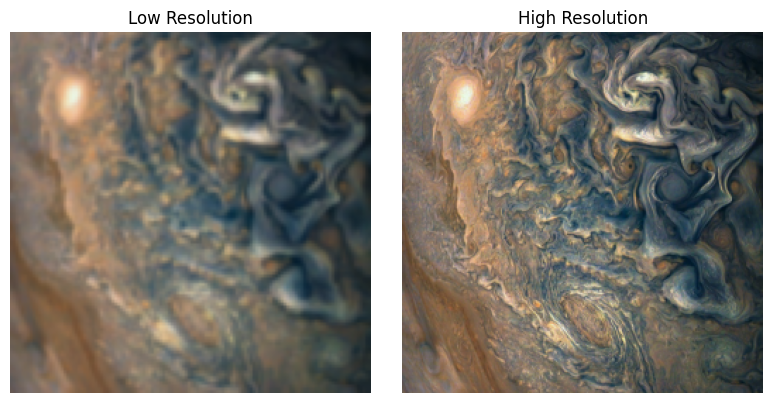

In [9]:
lr_batch, hr_batch = next(iter(train_loader))
print("LR batch shape:", lr_batch.shape)
print("HR batch shape:", hr_batch.shape)
# A quick visual check before starting model training
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(lr_batch[0].permute(1, 2, 0))
plt.title("Low Resolution")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(hr_batch[0].permute(1, 2, 0))
plt.title("High Resolution")
plt.axis("off")
plt.tight_layout()
plt.show()

#  verify that the loader returns correctly shaped LR-HR pairs
# before sending them into the SRGAN.

In [10]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1),
            nn.BatchNorm2d(out_channels),
            nn.PReLU()
        )

    def forward(self, x):
        return self.block(x)


#  this small block extracts image features while keeping the
# spatial size unchanged, and will be reused inside the generator.

In [11]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels),
            nn.PReLU(),
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels)
        )

    def forward(self, x):
        return x + self.layers(x)


#  residual learning lets the network refine existing features
# instead of rebuilding the complete image at every layer.

In [12]:
class Generator(nn.Module):
    def __init__(self, num_blocks=8):
        super().__init__()

        self.initial = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=9, stride=1, padding=4),
            nn.PReLU()
        )

        self.residuals = nn.Sequential(
            *[ResidualBlock(64) for _ in range(num_blocks)]
        )

        self.mid = nn.Sequential(
            nn.Conv2d(64, 64, 3, 1, 1),
            nn.BatchNorm2d(64)
        )

        self.upsample = nn.Sequential(
            nn.Conv2d(64, 256, 3, 1, 1),
            nn.PixelShuffle(2),
            nn.PReLU()
        )

        self.output = nn.Sequential(
            nn.Conv2d(64, 3, kernel_size=9, stride=1, padding=4),
            nn.Tanh()
        )

    def forward(self, x):
        first = self.initial(x)

        features = self.residuals(first)
        features = self.mid(features) + first

        features = self.upsample(features)

        return self.output(features)


#  the generator extracts features, improves them through residual
# blocks, upsamples the LR image by 2x, and produces the final SR image.

In [13]:
class DiscBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, stride, 1),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, x):
        return self.block(x)


# the discriminator gradually extracts features and reduces the
# image size while trying to separate real HR images from generated ones.

In [14]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1),
            nn.LeakyReLU(0.2, inplace=True),

            DiscBlock(64, 64, 2),
            DiscBlock(64, 128, 1),
            DiscBlock(128, 128, 2),
            DiscBlock(128, 256, 1),
            DiscBlock(256, 256, 2),
            DiscBlock(256, 512, 1),
            DiscBlock(512, 512, 2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


# the discriminator converts the image into a feature
# representation and finally gives a real/fake score.

In [15]:
generator = Generator().to(DEVICE)
discriminator = Discriminator().to(DEVICE)

print("Generator parameters:",
      sum(p.numel() for p in generator.parameters()))

print("Discriminator parameters:",
      sum(p.numel() for p in discriminator.parameters()))

# both networks are moved to the selected device and are now
# ready for adversarial training.

Generator parameters: 808845
Discriminator parameters: 4689601


In [16]:
vgg = vgg19(weights=VGG19_Weights.DEFAULT).features[:25].to(DEVICE)

for param in vgg.parameters():
    param.requires_grad = False

vgg.eval()

# Workflow: pretrained VGG features are used to compare the visual content
# of generated and real images instead of relying only on pixel differences.

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 180MB/s]  


Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

In [17]:
adversarial_loss = nn.BCEWithLogitsLoss()
content_loss = nn.MSELoss()

# adversarial loss helps the generator create realistic images,
# while content loss keeps the generated image close to the target image.

In [18]:
g_optimizer = optim.Adam(
    generator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.9, 0.999)
)

d_optimizer = optim.Adam(
    discriminator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.9, 0.999)
)

#  separate Adam optimizers update the generator and discriminator
# independently during the adversarial training process.

In [19]:
for epoch in range(NUM_EPOCHS):
    generator.train()
    discriminator.train()

    g_total = 0.0
    d_total = 0.0

    progress = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}")

    for lr_img, hr_img in progress:
        lr_img = lr_img.to(DEVICE)
        hr_img = hr_img.to(DEVICE)

        # -------------------------
        # Train discriminator
        # -------------------------
        fake_img = generator(lr_img)

        real_score = discriminator(hr_img)
        fake_score = discriminator(fake_img.detach())

        real_labels = torch.ones_like(real_score)
        fake_labels = torch.zeros_like(fake_score)

        d_loss_real = adversarial_loss(real_score, real_labels)
        d_loss_fake = adversarial_loss(fake_score, fake_labels)

        d_loss = (d_loss_real + d_loss_fake) / 2

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # -------------------------
        # Train generator
        # -------------------------
        fake_img = generator(lr_img)
        fake_score = discriminator(fake_img)

        pixel_loss = content_loss(fake_img, hr_img)

        fake_features = vgg(fake_img)
        real_features = vgg(hr_img).detach()

        perceptual_loss = content_loss(
            fake_features,
            real_features
        )

        g_loss = perceptual_loss + 1e-3 * adversarial_loss(
            fake_score,
            torch.ones_like(fake_score)
        )

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        g_total += g_loss.item()
        d_total += d_loss.item()

        progress.set_postfix(
            G=f"{g_loss.item():.3f}",
            D=f"{d_loss.item():.3f}"
        )

    print(
        f"Epoch {epoch + 1}: "
        f"G Loss = {g_total / len(train_loader):.4f}, "
        f"D Loss = {d_total / len(train_loader):.4f}"
    )

# first the discriminator learns real vs fake, then the generator
# is updated to produce images that look more realistic and match HR features.

Epoch 1/30: 100%|██████████| 43/43 [01:01<00:00,  1.42s/it, D=0.199, G=1.351]


Epoch 1: G Loss = 1.7756, D Loss = 0.3641


Epoch 2/30: 100%|██████████| 43/43 [01:05<00:00,  1.51s/it, D=0.071, G=1.087]


Epoch 2: G Loss = 1.2260, D Loss = 0.1328


Epoch 3/30: 100%|██████████| 43/43 [01:05<00:00,  1.51s/it, D=0.094, G=0.924]


...

Epoch 28: G Loss = 0.2916, D Loss = 0.0537


Epoch 29/30: 100%|██████████| 43/43 [01:06<00:00,  1.53s/it, D=0.027, G=0.200]


Epoch 29: G Loss = 0.2930, D Loss = 0.1745


Epoch 30/30: 100%|██████████| 43/43 [01:05<00:00,  1.53s/it, D=0.012, G=0.219]

Epoch 30: G Loss = 0.2836, D Loss = 0.0275


In [20]:
generator.eval()
with torch.no_grad():
    lr_img, hr_img = next(iter(val_loader))

    lr_img = lr_img.to(DEVICE)
    sr_img = generator(lr_img)

lr_img = lr_img.cpu()
sr_img = sr_img.cpu()
hr_img = hr_img.cpu()

print("Generated SR shape:", sr_img.shape)

# after training, the generator is tested on validation images
# that were not used for updating its weights.

Generated SR shape: torch.Size([16, 3, 256, 256])


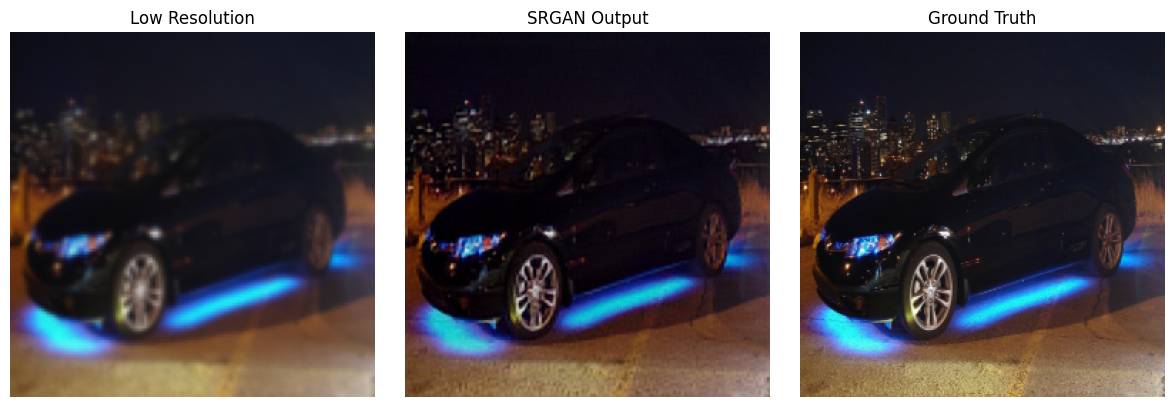

In [21]:
def show_results(lr, sr, hr, index=0):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(lr[index].permute(1, 2, 0).clamp(0, 1))
    plt.title("Low Resolution")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(sr[index].permute(1, 2, 0).clamp(0, 1))
    plt.title("SRGAN Output")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(hr[index].permute(1, 2, 0).clamp(0, 1))
    plt.title("Ground Truth")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


show_results(lr_img, sr_img, hr_img)

# this comparison lets us visually check whether the generated
# image has recovered useful details compared with the original HR image.

In [22]:
torch.save(
    generator.state_dict(),
    "srgan_generator.pth"
)

torch.save(
    discriminator.state_dict(),
    "srgan_discriminator.pth"
)

print("Models saved successfully.")

# save both networks so the trained generator can be reused later
# without training the complete SRGAN again.

Models saved successfully.


In [ ]:
def super_resolve(image_path):
    generator.eval()

    image = Image.open(image_path).convert("RGB")
    original_size = image.size

    lr = lr_transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        sr = generator(lr)

    sr = sr.squeeze(0).cpu().permute(1, 2, 0).clamp(0, 1).numpy()

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title(f"Input {original_size[0]}x{original_size[1]}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(sr)
    plt.title("Super-Resolved")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# Example:
# super_resolve("./test_image.jpg")

# new LR image is converted into a tensor, passed through the
# trained generator, and displayed alongside the original input.